# Heart Disease Prediction: Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) on the Statlog Heart Disease dataset from the UCI Machine Learning Repository.

The goal of this analysis is to:
- Understand the dataset structure
- Clean and preprocess the data
- Identify relationships between variables
- Visualize key medical indicators
- Build a baseline machine learning model for heart disease prediction

#Import Data and Other Important Libraries

In [1]:
# Importing required libraries for data handling, visualization, and machine learning
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")

In [51]:
# Loading the heart disease dataset from a public GitHub CSV file into a pandas DataFrame

heart_df = pd.read_csv("https://raw.githubusercontent.com/ashrivastav33/heart-disease-eda-ml/refs/heads/main/data/data.csv")

#Validating the data in the df
heart_df.head()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


In [18]:
#Performing Basic validations for the heart_df
heart_df.shape
heart_df.info()
heart_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   270 non-null    float64
 1   sex                   270 non-null    float64
 2   chest-pain            270 non-null    float64
 3   rest-bp               270 non-null    float64
 4   serum-chol            270 non-null    float64
 5   fasting-blood-sugar   270 non-null    float64
 6   electrocardiographic  270 non-null    float64
 7   max-heart-rate        270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  major-vessels         270 non-null    float64
 12  thal                  270 non-null    float64
 13  heart-disease         270 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 29.7 KB


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [20]:
#Validating if any null value is present in the dataframe
heart_df.isnull().sum()

,0
age,0
sex,0
chest-pain,0
rest-bp,0
serum-chol,0
fasting-blood-sugar,0
electrocardiographic,0
max-heart-rate,0
angina,0
oldpeak,0


As we can see we don't have any duplicates, hence data cleaning is not required and we are proceed with Exploratory Data Analysis

#Exploratory Data Analysis

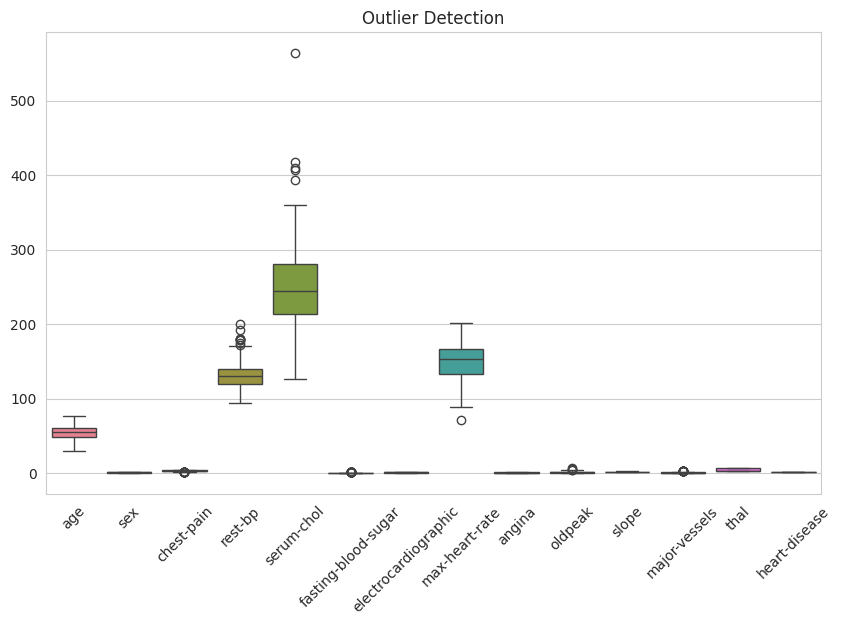

In [29]:
#Boxplot for all variables to visually detect potential outliers

plt.figure(figsize=(10,6))
sns.boxplot(data=heart_df)

plt.title("Outlier Detection")
plt.xticks(rotation=45)  # rotate x-axis labels by 45 degrees

plt.show()

Text(0.5, 1.0, 'Cholesterol Outliers')

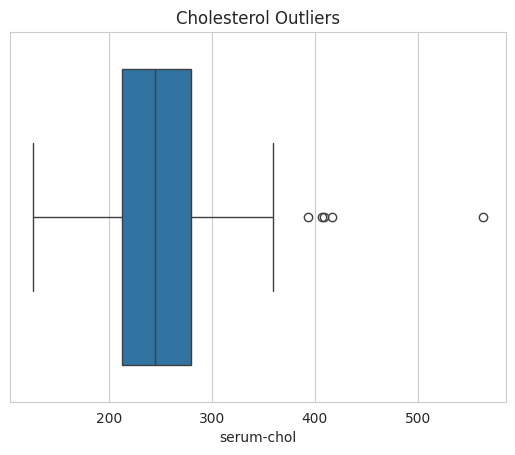

In [79]:
#Box-plot showcasing Cholesterol Outliers
sns.boxplot(x=heart_df['serum-chol'])
plt.title("Cholesterol Outliers")

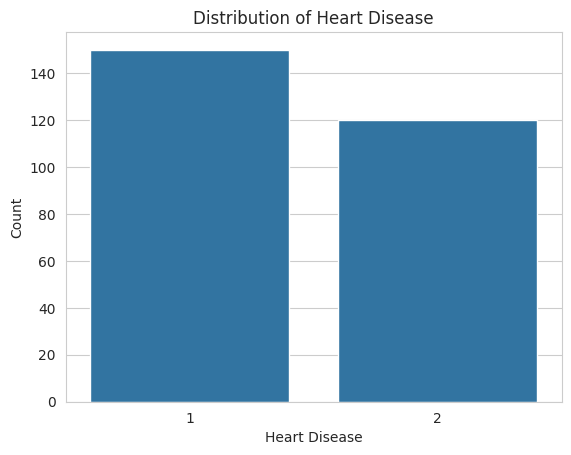

In [56]:
#Box Plot showcasing Distribution of Heart Disease
sns.countplot(x='heart-disease', data=heart_df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

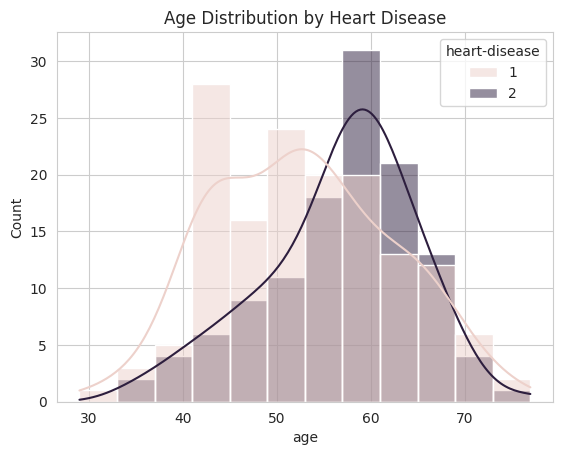

In [39]:
#Age Distribution by Heart Disease
sns.histplot(data=heart_df, x="age", hue="heart-disease", kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

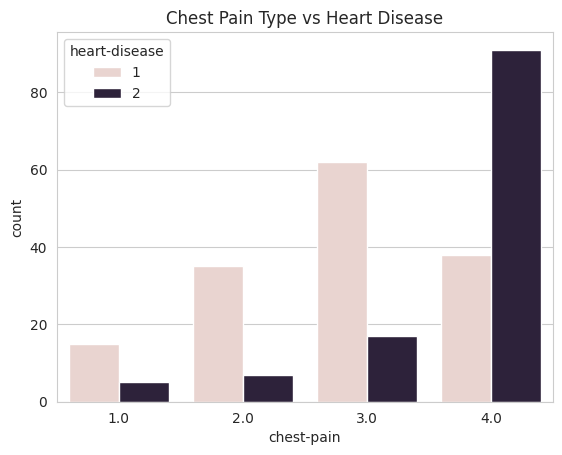

In [73]:
#Chest Pain vs Heart Disease
sns.countplot(x='chest-pain', hue='heart-disease', data=heart_df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

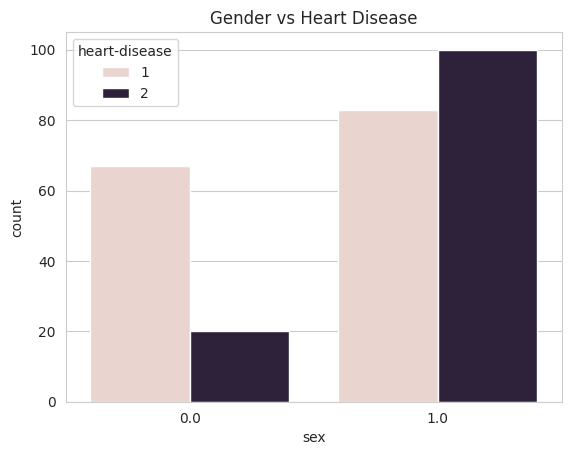

In [75]:
#Gender vs Heart Disease

sns.countplot(x='sex', hue='heart-disease', data=heart_df)
plt.title("Gender vs Heart Disease")
plt.show()

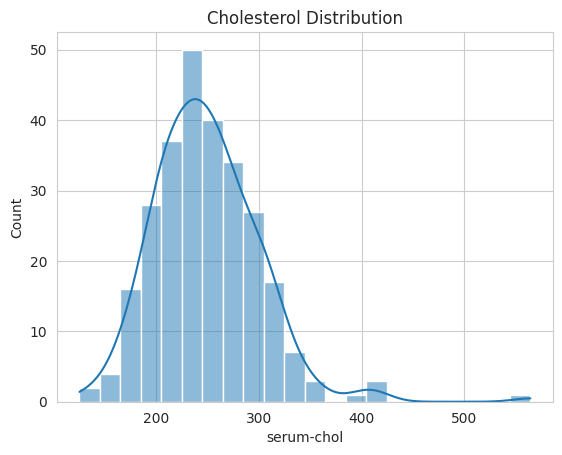

In [80]:
#Cholestrol Distribution
sns.histplot(heart_df['serum-chol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

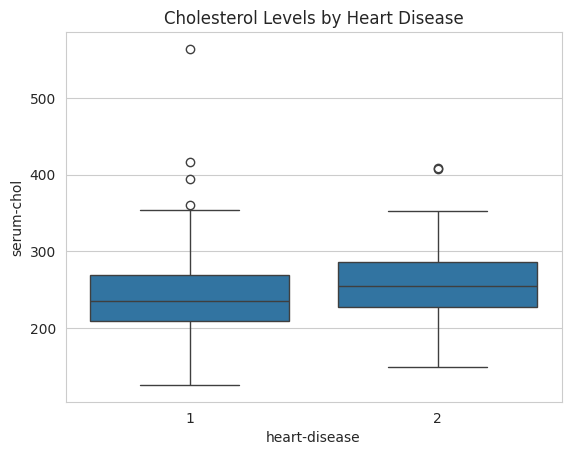

In [81]:
#Cholesterol Levels by Heart Disease
sns.boxplot(x='heart-disease', y='serum-chol', data=heart_df)
plt.title("Cholesterol Levels by Heart Disease")
plt.show()

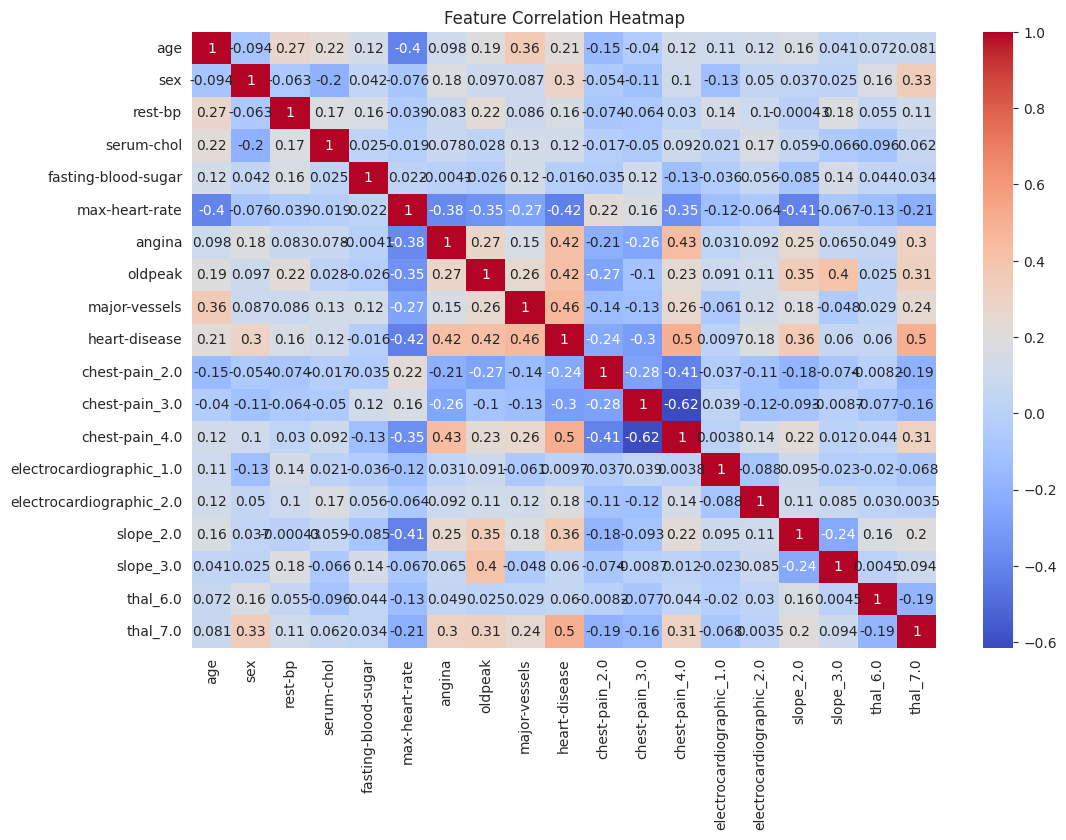

In [82]:
#Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

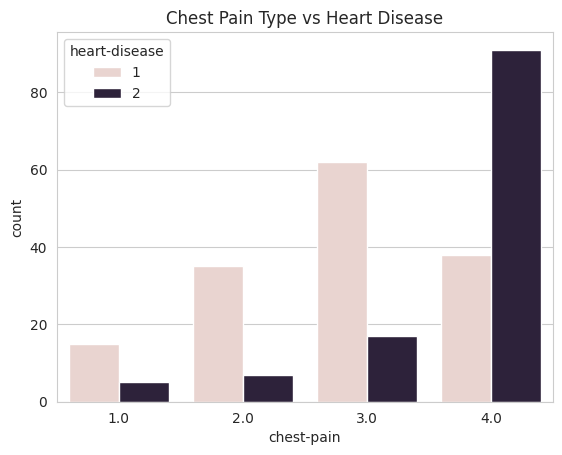

In [83]:
#Chest Pain Type vs Heart Disease
sns.countplot(x='chest-pain', hue='heart-disease', data=heart_df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

# Feature Engineering & ML

In [58]:
# Converting categorical columns into numerical format using one-hot encoding

categorical_cols = ['chest-pain', 'electrocardiographic', 'slope', 'thal']
df = pd.get_dummies(heart_df, columns=categorical_cols, drop_first=True)

X = df.drop('heart-disease', axis=1)
y = df['heart-disease']

In [63]:
#Data split to perform training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
## Using Logistic Regression model, using max_iteraion
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
## Evaluating model performance
# y_pred -> predicted class labels
# y_prob -> predicted probabilities used for ROC/AUC metrics
from sklearn.metrics import roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('Accuracy:', round(accuracy,4))
print('ROC-AUC:', round(roc_auc,4))

Accuracy: 0.8704
ROC-AUC: 0.9466


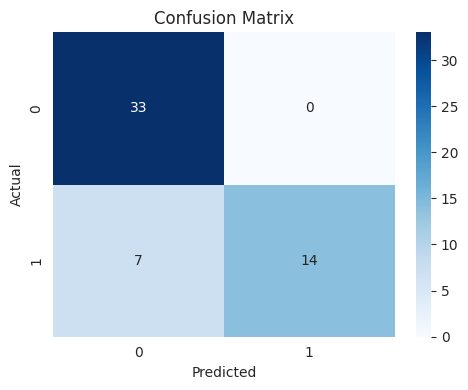

In [67]:
#Checking Confusion Matrix to see between FP, FN, TP, TN
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

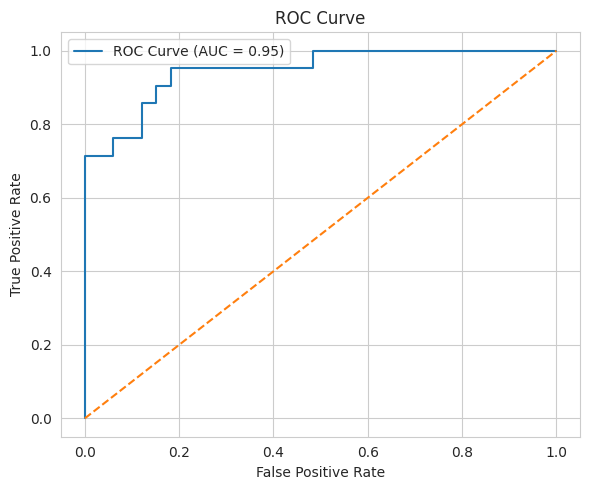

In [84]:
from sklearn.metrics import roc_curve

false_postive_rate, true_postive_rate, _ = roc_curve(y_test, y_prob, pos_label=2)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

This analysis explored the Statlog Heart Disease dataset to understand the relationships between clinical variables and the presence of heart disease. The dataset was cleaned by checking for missing values and duplicates, followed by exploratory data analysis to identify patterns and correlations between variables.

Key insights from the analysis include:

- Age and chest pain type appear to be strong indicators associated with heart disease.
- Maximum heart rate and exercise-induced angina show noticeable differences between patients with and without heart disease.
- Correlation analysis revealed moderate relationships between several clinical features and the target variable.

A baseline Logistic Regression model was implemented to predict the presence of heart disease.

### Model Performance

The baseline model achieved the following results:

- **Accuracy:** 0.8704
- **ROC-AUC:** 0.9466

These results indicate that the model performs well at distinguishing between patients with and without heart disease. The high ROC-AUC score suggests strong classification capability across different probability thresholds.

### Future Work

Further improvements could include:
- Testing additional models such as Random Forest, Gradient Boosting, or Support Vector Machines.
- Performing hyperparameter tuning to improve predictive performance.
- Applying feature scaling and advanced feature engineering techniques.